# Ejercicio 12: Multimodal Embeddings

### **Estudiante:** Kevin Alvear

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

In [1]:
import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor
import random

# Cargar modelo CLIP y su procesador
model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"Modelo CLIP cargado en {device}.")
print(f"Dimensión de los embeddings: {model.projection_dim}")

C:\Users\Kevin Alvear\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Kevin Alvear\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Kevin Alvear\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://hu

Modelo CLIP cargado en cpu.
Dimensión de los embeddings: 512


In [2]:
# Cargar CIFAR-10 (solo 100 imágenes aleatorias para rapidez)
cifar = CIFAR10(root="./data", train=True, download=True, transform=ToTensor())
num_samples = 100
indices = random.sample(range(len(cifar)), num_samples)
images = []
labels = []
for idx in indices:
    img, label = cifar[idx]
    # Convertir tensor (C, H, W) a PIL (H, W, C) para CLIP
    img = (img * 255).byte().permute(1, 2, 0).numpy()
    img_pil = Image.fromarray(img)
    images.append(img_pil)
    labels.append(label)

class_names = cifar.classes
print(f"Cargadas {len(images)} imágenes de CIFAR-10.")
print("Clases:", class_names)

100%|██████████| 170M/170M [1:15:44<00:00, 37.5kB/s] 
C:\Users\Kevin Alvear\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Cargadas 100 imágenes de CIFAR-10.
Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [10]:
# Generar embeddings de imágenes APLICANDO LA PROYECCIÓN FINAL
image_inputs = processor(images=images, return_tensors="pt", padding=True)
image_inputs = {k: v.to(device) for k, v in image_inputs.items()}
with torch.no_grad():
    vision_outputs = model.vision_model(pixel_values=image_inputs['pixel_values'])
    # Proyectar al espacio común
    image_embeds = model.visual_projection(vision_outputs.pooler_output)
    image_embeds = image_embeds.cpu().numpy()

# Generar embeddings de textos APLICANDO LA PROYECCIÓN FINAL
text_inputs = processor(text=text_prompts, return_tensors="pt", padding=True)
text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
with torch.no_grad():
    text_outputs = model.text_model(input_ids=text_inputs['input_ids'], attention_mask=text_inputs['attention_mask'])
    # Proyectar al espacio común
    text_embeds = model.text_projection(text_outputs.pooler_output)
    text_embeds = text_embeds.cpu().numpy()

print(f"Embeddings de imágenes: {image_embeds.shape}")
print(f"Embeddings de textos: {text_embeds.shape}")
print("Dimensión común:", model.projection_dim)

Embeddings de imágenes: (100, 512)
Embeddings de textos: (10, 512)
Dimensión común: 512


Varianza explicada por PC1 y PC2: [0.2853767  0.10492953]


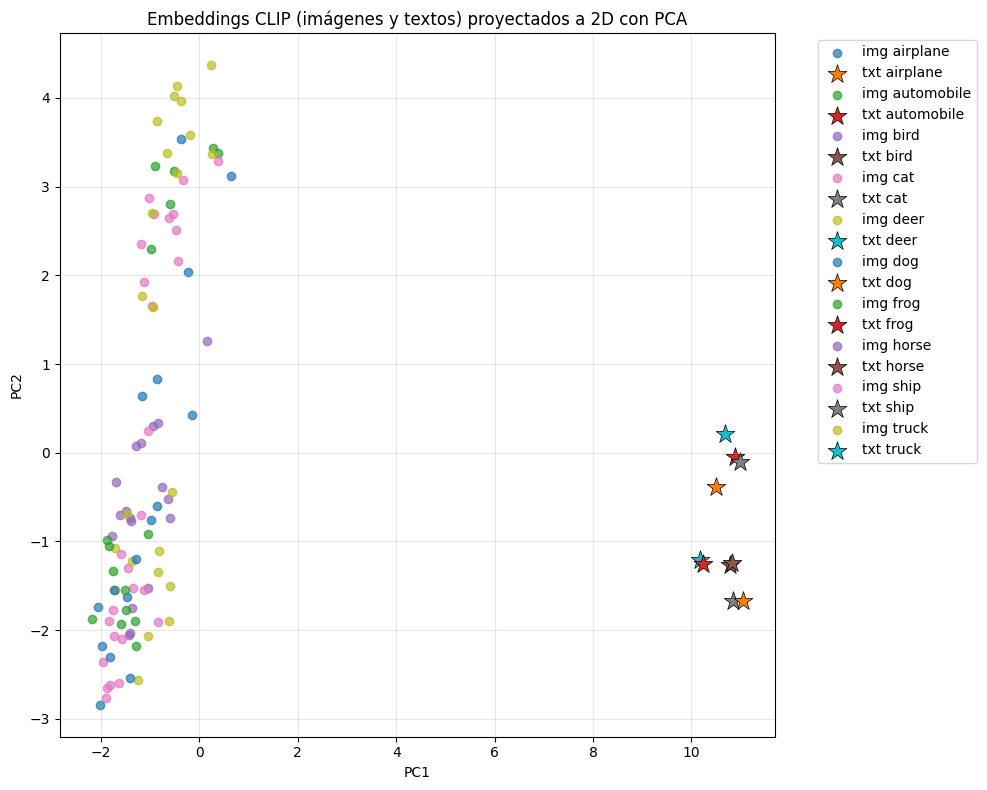

In [11]:
# Combinar embeddings de imágenes y textos para PCA
combined = np.vstack([image_embeds, text_embeds])
labels_combined = [f"img_{i}" for i in range(len(images))] + [f"txt_{c}" for c in range(len(class_names))]
classes_combined = [labels[i] for i in range(len(images))] + list(range(len(class_names)))

# Reducir a 2D con PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(combined)
print("Varianza explicada por PC1 y PC2:", pca.explained_variance_ratio_)

# Graficar
plt.figure(figsize=(10, 8))
# Imágenes: puntos con color según clase
for cls in set(labels):
    idx_img = [i for i in range(len(images)) if labels[i] == cls]
    idx_txt = [len(images) + cls]  # el texto correspondiente está en esa posición
    # Puntos de imágenes
    plt.scatter(coords[idx_img, 0], coords[idx_img, 1],
                label=f"img {class_names[cls]}", alpha=0.7, marker='o')
    # Punto del texto (marcador estrella)
    plt.scatter(coords[idx_txt, 0], coords[idx_txt, 1],
                s=200, marker='*', edgecolors='black', linewidth=0.5,
                label=f"txt {class_names[cls]}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Embeddings CLIP (imágenes y textos) proyectados a 2D con PCA")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Query de texto: 'a photo of a dog'


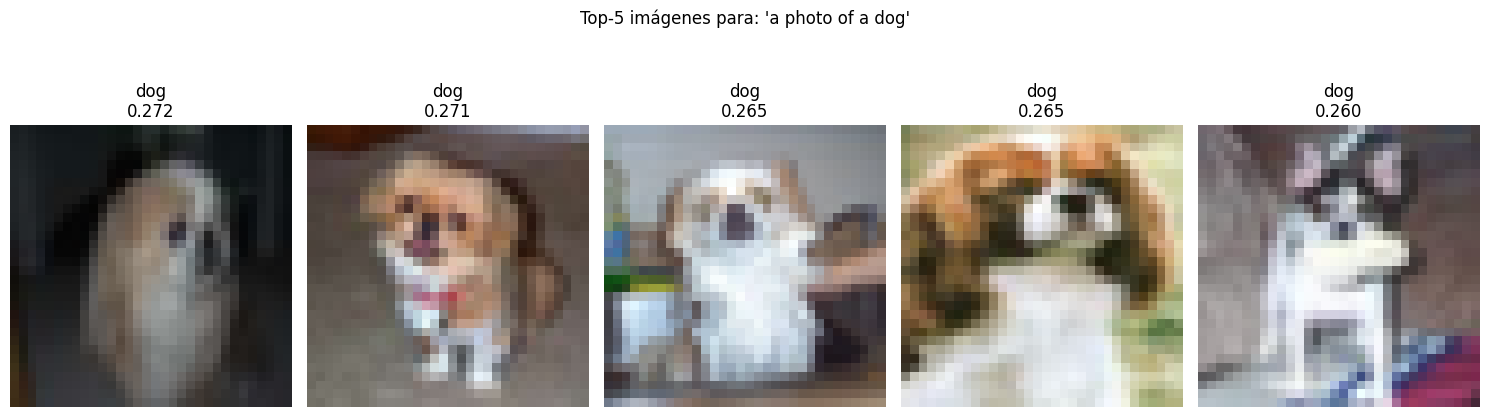

In [12]:
# Función de similitud coseno
def cosine_similarity(a, b):
    a = a / np.linalg.norm(a, axis=1, keepdims=True)
    b = b / np.linalg.norm(b, axis=1, keepdims=True)
    return np.dot(a, b.T)

# Normalizar embeddings para búsqueda
image_embeds_norm = image_embeds / np.linalg.norm(image_embeds, axis=1, keepdims=True)
text_embeds_norm = text_embeds / np.linalg.norm(text_embeds, axis=1, keepdims=True)

# Elegir un texto de consulta
query_text = "a photo of a dog"
print(f"Query de texto: '{query_text}'")

# Obtener embedding del texto consultado (con proyección)
query_inputs = processor(text=[query_text], return_tensors="pt", padding=True)
query_inputs = {k: v.to(device) for k, v in query_inputs.items()}
with torch.no_grad():
    query_text_outputs = model.text_model(input_ids=query_inputs['input_ids'], attention_mask=query_inputs['attention_mask'])
    query_emb = model.text_projection(query_text_outputs.pooler_output).cpu().numpy()
query_emb = query_emb / np.linalg.norm(query_emb)

# Similitud con todas las imágenes
sim = np.dot(image_embeds_norm, query_emb.T).flatten()
top_k = 5
top_indices = np.argsort(sim)[-top_k:][::-1]

# Mostrar imágenes más similares
fig, axes = plt.subplots(1, top_k, figsize=(15, 5))
for i, idx in enumerate(top_indices):
    axes[i].imshow(images[idx])
    axes[i].set_title(f"{class_names[labels[idx]]}\n{sim[idx]:.3f}")
    axes[i].axis('off')
plt.suptitle(f"Top-{top_k} imágenes para: '{query_text}'")
plt.tight_layout()
plt.show()

Imagen de consulta: clase real = bird
Textos más similares a la imagen (con sus puntuaciones):
1. a photo of a bird (similitud: 0.2939)
2. a photo of a frog (similitud: 0.2381)
3. a photo of a dog (similitud: 0.2322)
4. a photo of a cat (similitud: 0.2243)
5. a photo of a horse (similitud: 0.2239)


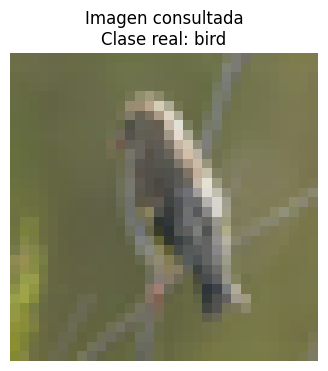

In [13]:
# Elegir una imagen de consulta (la primera de la muestra)
query_img = images[0]
print(f"Imagen de consulta: clase real = {class_names[labels[0]]}")

# Obtener embedding de la imagen consultada (con proyección)
img_inputs = processor(images=[query_img], return_tensors="pt", padding=True)
img_inputs = {k: v.to(device) for k, v in img_inputs.items()}
with torch.no_grad():
    query_img_vision_outputs = model.vision_model(pixel_values=img_inputs['pixel_values'])
    query_img_emb = model.visual_projection(query_img_vision_outputs.pooler_output).cpu().numpy()
query_img_emb = query_img_emb / np.linalg.norm(query_img_emb)

# Similitud con todos los textos (los prompts de las clases)
sim_text = np.dot(text_embeds_norm, query_img_emb.T).flatten()
top_texts = np.argsort(sim_text)[-5:][::-1]

# Mostrar los textos más similares
print("Textos más similares a la imagen (con sus puntuaciones):")
for rank, idx in enumerate(top_texts):
    print(f"{rank+1}. {text_prompts[idx]} (similitud: {sim_text[idx]:.4f})")

# Mostrar la imagen consultada
plt.figure(figsize=(4, 4))
plt.imshow(query_img)
plt.title(f"Imagen consultada\nClase real: {class_names[labels[0]]}")
plt.axis('off')
plt.show()